In [ ]:
from pathlib import Path
import json
import os
import time

import jiwer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torchaudio

from wav2vec2decoder import Wav2Vec2Decoder

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

LIBRI_MANIFEST = 'data/librispeech_test_other/manifest.csv'
EARN_MANIFEST = 'data/earnings22_test/manifest.csv'
LM_3GRAM = 'lm/3-gram.pruned.1e-7.arpa.gz'
FINANCIAL_LM = 'lm/financial-3gram.arpa.gz'
LM_4GRAM = 'lm/4-gram.arpa.gz'


class AudioDataset:
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        waveform, sample_rate = torchaudio.load(row['path'])
        return waveform, sample_rate, row['text']


def load_dataset(manifest_path):
    dataset = AudioDataset(manifest_path)
    samples = []
    for idx in range(len(dataset)):
        audio, sr, text = dataset[idx]
        assert sr == 16000, f'Expected 16 kHz, got {sr} for sample {idx}'
        samples.append((audio, text))
    return dataset, samples


def save_results(name, data):
    path = RESULTS_DIR / f'{name}.json'
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f'saved -> {path}')


def load_results(name):
    path = RESULTS_DIR / f'{name}.json'
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def configure_decoder(decoder, beam_width=None, alpha=None, beta=None, temperature=None):
    if beam_width is not None:
        decoder.beam_width = beam_width
    if alpha is not None:
        decoder.alpha = alpha
    if beta is not None:
        decoder.beta = beta
    if temperature is not None:
        decoder.temperature = temperature


def evaluate_method(decoder, samples, method):
    references = []
    hypotheses = []
    for audio, ref in samples:
        hypotheses.append(decoder.decode(audio, method=method))
        references.append(ref)
    wer = jiwer.wer(references, hypotheses)
    cer = jiwer.cer(references, hypotheses)
    return wer, cer, hypotheses

def print_header(title):
    print('\n' + '=' * 70)
    print(title)
    print('=' * 70)


def plot_line(xs, ys, title, xlabel, ylabel, marker='o', color=None):
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys, marker=marker, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_beam_width_results(results_dict):
    df = pd.DataFrame(results_dict).T.reset_index().rename(columns={'index': 'beam_width'})
    df['beam_width'] = df['beam_width'].astype(int)
    df = df.sort_values('beam_width')

    ks = df['beam_width'].tolist()
    wers = (df['wer'] * 100).tolist()
    cers = (df['cer'] * 100).tolist()
    times = df['time'].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(ks, wers, marker='o')
    axes[0].set_title('WER vs beam width')
    axes[0].set_xlabel('beam width')
    axes[0].set_ylabel('WER, %')
    axes[0].set_xticks(ks)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ks, cers, marker='o', color='orange')
    axes[1].set_title('CER vs beam width')
    axes[1].set_xlabel('beam width')
    axes[1].set_ylabel('CER, %')
    axes[1].set_xticks(ks)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(ks, times, marker='o', color='green')
    axes[2].set_title('Decoding time vs beam width')
    axes[2].set_xlabel('beam width')
    axes[2].set_ylabel('time, sec')
    axes[2].set_xticks(ks)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return df


def plot_temperature_results(results_dict, title_prefix='Task 3'):
    df = pd.DataFrame(results_dict).T.reset_index().rename(columns={'index': 'temperature'})
    df['temperature'] = df['temperature'].astype(float)
    df = df.sort_values('temperature')

    temps = df['temperature'].tolist()
    wer_col = 'wer' if 'wer' in df.columns else 'greedy_wer'
    cer_col = 'cer' if 'cer' in df.columns else None

    if cer_col is not None:
        wers = (df[wer_col] * 100).tolist()
        cers = (df[cer_col] * 100).tolist()
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(temps, wers, marker='o', color='blue')
        axes[0].set_title(f'{title_prefix}: WER vs temperature')
        axes[0].set_xlabel('temperature')
        axes[0].set_ylabel('WER, %')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(temps, cers, marker='o', color='orange')
        axes[1].set_title(f'{title_prefix}: CER vs temperature')
        axes[1].set_xlabel('temperature')
        axes[1].set_ylabel('CER, %')
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        plot_line(temps, df[wer_col].tolist(), f'{title_prefix}: WER vs temperature', 'temperature', 'WER')

    return df


def plot_task7b_results(results_dict):
    df = pd.DataFrame(results_dict).T.reset_index().rename(columns={'index': 'temperature'})
    df['temperature'] = df['temperature'].astype(float)
    df = df.sort_values('temperature')

    plt.figure(figsize=(7, 4))
    plt.plot(df['temperature'], df['greedy_wer'] * 100, marker='o', label='Greedy WER')
    plt.plot(df['temperature'], df['sf_wer'] * 100, marker='s', label='Shallow Fusion WER')
    plt.title('Task 7b: Earnings22 WER vs temperature')
    plt.xlabel('temperature')
    plt.ylabel('WER, %')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return df


def plot_grid_from_results(results_dict, title, value_key='wer'):
    rows = []

    for key, value in results_dict.items():
        if key == 'best':
            continue
        if isinstance(value, dict) and 'alpha' in value and 'beta' in value and value_key in value:
            rows.append(value)

    df = pd.DataFrame(rows)
    df = df.sort_values(['alpha', 'beta'])

    pivot = df.pivot(index='alpha', columns='beta', values=value_key).sort_index()

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')

    ax.set_title(title)
    ax.set_xlabel('beta')
    ax.set_ylabel('alpha')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(x) for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(x) for x in pivot.index])

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(
                j,
                i,
                f'{pivot.values[i, j] * 100:.2f}',
                ha='center',
                va='center',
                color='white',
                fontsize=9,
            )

    fig.colorbar(im, ax=ax, label=value_key.upper())
    plt.tight_layout()
    plt.show()

    return pivot


def run_task1(samples, decoder_no_lm, sample_prefix='librispeech'):
    print_header('Task 1: Greedy decoding on LibriSpeech')
    configure_decoder(decoder_no_lm, temperature=1.0)
    t0 = time.time()
    wer, cer, _ = evaluate_method(decoder_no_lm, samples, 'greedy')
    elapsed = time.time() - t0
    data = {'wer': wer, 'cer': cer, 'time': elapsed}
    save_results('task1_greedy', data)
    print(data)
    return data


def run_task2(samples, decoder_no_lm, sample_prefix='librispeech'):
    print_header('Task 2: Beam search sweep by beam_width')
    configure_decoder(decoder_no_lm, temperature=1.0)
    results = {}
    for bw in [1, 3, 10, 50]:
        configure_decoder(decoder_no_lm, beam_width=bw)
        t0 = time.time()
        wer, cer, _ = evaluate_method(decoder_no_lm, samples, 'beam')
        results[str(bw)] = {'wer': wer, 'cer': cer, 'time': time.time() - t0}
        print(f'beam_width={bw}: WER={wer:.4f}, CER={cer:.4f}')
    save_results('task2_beam_widths', results)
    return results


def run_task3(samples, decoder_no_lm, sample_prefix='librispeech'):
    print_header('Task 3: Greedy temperature sweep')
    results = {}
    for temp in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
        configure_decoder(decoder_no_lm, temperature=temp)
        wer, cer, _ = evaluate_method(decoder_no_lm, samples, 'greedy')
        results[str(temp)] = {'wer': wer, 'cer': cer}
        print(f'T={temp}: WER={wer:.4f}, CER={cer:.4f}')
    save_results('task3_temperature_greedy', results)
    return results


def run_task4(samples, decoder_lm):
    print_header('Task 4: Shallow fusion sweep')
    configure_decoder(decoder_lm, beam_width=10, temperature=1.0)
    alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
    betas = [0.0, 0.5, 1.0, 1.5]
    results = {}
    best_wer = float('inf')
    best_params = None
    for alpha in alphas:
        for beta in betas:
            configure_decoder(decoder_lm, alpha=alpha, beta=beta)
            wer, cer, _ = evaluate_method(decoder_lm, samples, 'beam_lm')
            key = f'a{alpha}_b{beta}'
            results[key] = {'alpha': alpha, 'beta': beta, 'wer': wer, 'cer': cer}
            if wer < best_wer:
                best_wer = wer
                best_params = (alpha, beta)
            print(f'alpha={alpha}, beta={beta}: WER={wer:.4f}, CER={cer:.4f}')
    results['best'] = {'alpha': best_params[0], 'beta': best_params[1], 'wer': best_wer}
    save_results('task4_shallow_fusion_sweep', results)
    print('best shallow fusion:', results['best'])
    return best_params


def run_task5(samples, best_params):
    print_header('Task 5: 4-gram LM evaluation')
    if not Path(LM_4GRAM).exists():
        print(f'Skip: {LM_4GRAM} not found')
        return None
    decoder = Wav2Vec2Decoder(lm_model_path=LM_4GRAM, beam_width=10)
    configure_decoder(decoder, alpha=best_params[0], beta=best_params[1], temperature=1.0)
    wer, cer, _ = evaluate_method(decoder, samples, 'beam_lm')
    result = {'alpha': best_params[0], 'beta': best_params[1], 'wer': wer, 'cer': cer}
    save_results('task5_4gram_eval', result)
    print(result)
    return result


def run_task6(samples, decoder_lm):
    print_header('Task 6: LM rescoring sweep')
    configure_decoder(decoder_lm, beam_width=50, temperature=1.0)
    alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
    betas = [0.0, 0.5, 1.0, 1.5]
    results = {}
    best_wer = float('inf')
    best_params = None
    for alpha in alphas:
        for beta in betas:
            configure_decoder(decoder_lm, alpha=alpha, beta=beta)
            wer, cer, _ = evaluate_method(decoder_lm, samples, 'beam_lm_rescore')
            key = f'a{alpha}_b{beta}'
            results[key] = {'alpha': alpha, 'beta': beta, 'wer': wer, 'cer': cer}
            if wer < best_wer:
                best_wer = wer
                best_params = (alpha, beta)
            print(f'alpha={alpha}, beta={beta}: WER={wer:.4f}, CER={cer:.4f}')
    results['best'] = {'alpha': best_params[0], 'beta': best_params[1], 'wer': best_wer}
    save_results('task6_rescoring_sweep', results)
    print('best rescoring:', results['best'])
    return best_params


def run_task6_qualitative(samples, decoder_lm, sf_params, rs_params, limit=10):
    print_header('Task 6: Qualitative examples')
    configure_decoder(decoder_lm, beam_width=10, temperature=1.0)
    _, _, beam_hyps = evaluate_method(decoder_lm, samples, 'beam')

    configure_decoder(decoder_lm, beam_width=10, alpha=sf_params[0], beta=sf_params[1], temperature=1.0)
    _, _, sf_hyps = evaluate_method(decoder_lm, samples, 'beam_lm')

    configure_decoder(decoder_lm, beam_width=50, alpha=rs_params[0], beta=rs_params[1], temperature=1.0)
    _, _, rs_hyps = evaluate_method(decoder_lm, samples, 'beam_lm_rescore')

    examples = []
    for idx, ((_, ref), beam, sf, rs) in enumerate(zip(samples, beam_hyps, sf_hyps, rs_hyps)):
        if beam != sf or beam != rs:
            examples.append({'idx': idx, 'ref': ref, 'beam': beam, 'sf': sf, 'rs': rs})

    examples = examples[:limit]
    save_results('task6_qualitative', examples)
    print(f'Saved {len(examples)} qualitative examples')
    return examples


def run_task7(libri_samples, earn_samples, decoder_no_lm, decoder_lm, sf_params, rs_params):
    print_header('Task 7: Cross-domain comparison')
    results = {}
    for dataset_name, samples in [('librispeech', libri_samples), ('earnings22', earn_samples)]:
        results[dataset_name] = {}

        configure_decoder(decoder_no_lm, beam_width=10, temperature=1.0)
        wer, cer, _ = evaluate_method(decoder_no_lm, samples, 'greedy')
        results[dataset_name]['greedy'] = {'wer': wer, 'cer': cer}

        configure_decoder(decoder_no_lm, beam_width=10, temperature=1.0)
        wer, cer, _ = evaluate_method(decoder_no_lm, samples, 'beam')
        results[dataset_name]['beam'] = {'wer': wer, 'cer': cer}

        configure_decoder(decoder_lm, beam_width=10, alpha=sf_params[0], beta=sf_params[1], temperature=1.0)
        wer, cer, _ = evaluate_method(decoder_lm, samples, 'beam_lm')
        results[dataset_name]['beam_lm'] = {'wer': wer, 'cer': cer}

        configure_decoder(decoder_lm, beam_width=50, alpha=rs_params[0], beta=rs_params[1], temperature=1.0)
        wer, cer, _ = evaluate_method(decoder_lm, samples, 'beam_lm_rescore')
        results[dataset_name]['beam_lm_rs'] = {'wer': wer, 'cer': cer}

    save_results('task7_cross_domain', results)
    return results


def run_task7b(earn_samples, decoder_no_lm, decoder_lm, sf_params):
    print_header('Task 7b: Temperature sweep on Earnings22')
    results = {}
    for temp in [0.5, 1.0, 1.5, 2.0]:
        configure_decoder(decoder_no_lm, beam_width=10, temperature=temp)
        greedy_wer, _, _ = evaluate_method(decoder_no_lm, earn_samples, 'greedy')

        configure_decoder(decoder_lm, beam_width=10, alpha=sf_params[0], beta=sf_params[1], temperature=temp)
        sf_wer, _, _ = evaluate_method(decoder_lm, earn_samples, 'beam_lm')

        results[str(temp)] = {'greedy_wer': greedy_wer, 'sf_wer': sf_wer}
        print(f'T={temp}: greedy={greedy_wer:.4f}, sf={sf_wer:.4f}')
    save_results('task7b_temp_earnings22', results)
    return results

def run_task9(libri_samples, earn_samples, sf_params, rs_params):
    print_header('Task 9: Compare LibriSpeech LM vs Financial LM')
    if not Path(FINANCIAL_LM).exists():
        print(f'Skip: {FINANCIAL_LM} not found')
        return None

    results = {}
    for lm_name, lm_path in [('librispeech_3gram', LM_3GRAM), ('financial_3gram', FINANCIAL_LM)]:
        decoder = Wav2Vec2Decoder(lm_model_path=lm_path, beam_width=10)
        results[lm_name] = {}
        for ds_name, samples in [('librispeech', libri_samples), ('earnings22', earn_samples)]:
            configure_decoder(decoder, beam_width=10, alpha=sf_params[0], beta=sf_params[1], temperature=1.0)
            wer_sf, cer_sf, _ = evaluate_method(decoder, samples, 'beam_lm')

            configure_decoder(decoder, beam_width=50, alpha=rs_params[0], beta=rs_params[1], temperature=1.0)
            wer_rs, cer_rs, _ = evaluate_method(decoder, samples, 'beam_lm_rescore')

            results[lm_name][ds_name] = {
                'sf': {'wer': wer_sf, 'cer': cer_sf},
                'rs': {'wer': wer_rs, 'cer': cer_rs},
            }
    save_results('task9_lm_comparison', results)
    return results


print('Results dir:', RESULTS_DIR.resolve())

Results dir: /netapp/a.gorokhova/itmo/Speech_ITMO/assignment2/results


In [ ]:
print('Loading datasets...')
libri_dataset, libri_samples = load_dataset(LIBRI_MANIFEST)
earn_dataset, earn_samples = load_dataset(EARN_MANIFEST)

print(f'LibriSpeech samples: {len(libri_dataset)}')
print(f'Earnings22 samples: {len(earn_dataset)}')
print('LibriSpeech manifest preview:')
display(libri_dataset.data.head())

print('Initializing decoders...')
decoder_no_lm = Wav2Vec2Decoder(lm_model_path=None)
decoder_lm = Wav2Vec2Decoder(lm_model_path=LM_3GRAM)

print('Ready')

Loading datasets...
LibriSpeech samples: 200
Earnings22 samples: 200
LibriSpeech manifest preview:


,path,text
0,data/librispeech_test_other/sample_0.wav,i am from the cutter lying off the coast
1,data/librispeech_test_other/sample_1.wav,don't cry he said i was obliged to come
2,data/librispeech_test_other/sample_2.wav,and and you have not found out anything came i...
3,data/librispeech_test_other/sample_3.wav,i wish you would believe me that i am in as gr...
4,data/librispeech_test_other/sample_4.wav,that my father sir risdon graeme has smuggled ...


Initializing decoders...


/ssd/a.gorokhova/usr/anaconda3/envs/audio_itmo/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForS

Ready


Loading the LM will be faster if you build a binary file.
Reading /netapp/a.gorokhova/itmo/Speech_ITMO/assignment2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


## Tasks 1–3

In [12]:
task1 = run_task1(libri_samples, decoder_no_lm)
task2 = run_task2(libri_samples, decoder_no_lm)
task3 = run_task3(libri_samples, decoder_no_lm)

print(task1)
print(task2)
print(task3)

I0000 00:00:1774300117.861151 1207930 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



Task 1: Greedy decoding on LibriSpeech


I0000 00:00:1774300117.911171 1207930 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774300119.324831 1207930 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


saved -> results/task1_greedy.json
{'wer': 0.11219750672207285, 'cer': 0.038127997674531275, 'time': 30.53710675239563}

Task 2: Beam search sweep by beam_width
beam_width=1: WER=0.1124, CER=0.0380
beam_width=3: WER=0.1115, CER=0.0378
beam_width=10: WER=0.1107, CER=0.0377
beam_width=50: WER=0.1110, CER=0.0377
saved -> results/task2_beam_widths.json

Task 3: Greedy temperature sweep
T=0.5: WER=0.1122, CER=0.0381
T=0.8: WER=0.1122, CER=0.0381
T=1.0: WER=0.1122, CER=0.0381
T=1.2: WER=0.1122, CER=0.0381
T=1.5: WER=0.1122, CER=0.0381
T=2.0: WER=0.1122, CER=0.0381
saved -> results/task3_temperature_greedy.json
{'wer': 0.11219750672207285, 'cer': 0.038127997674531275, 'time': 30.53710675239563}
{'1': {'wer': 0.11244194573453924, 'cer': 0.03803110314422751, 'time': 35.344982624053955}, '3': {'wer': 0.11146418968467367, 'cer': 0.03783731408361998, 'time': 63.58675670623779}, '10': {'wer': 0.1107308726472745, 'cer': 0.03769197228816433, 'time': 127.8634660243988}, '50': {'wer': 0.110975311659740

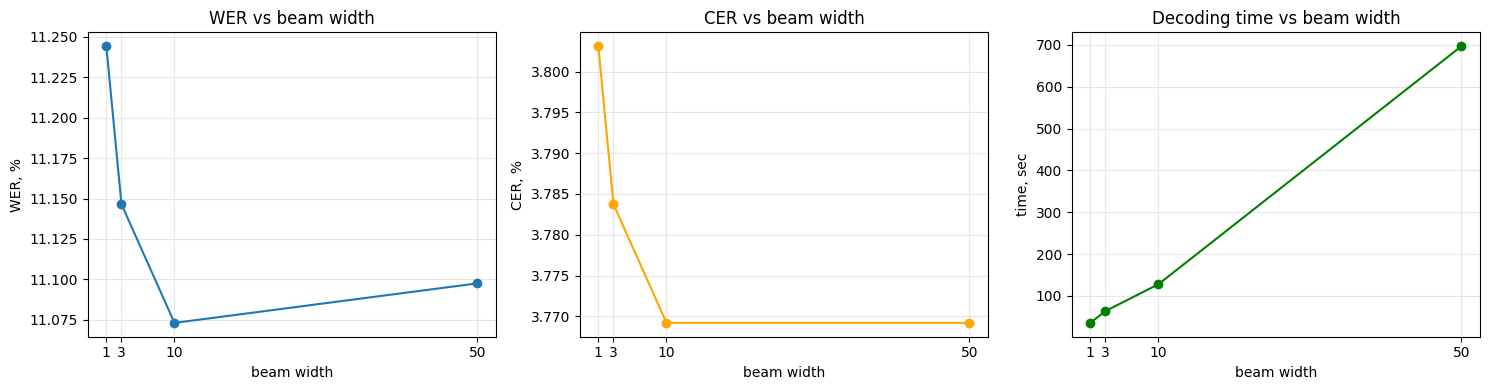

,beam_width,wer,cer,time
0,1,0.112442,0.038031,35.344983
1,3,0.111464,0.037837,63.586757
2,10,0.110731,0.037692,127.863466
3,50,0.110975,0.037692,696.921584


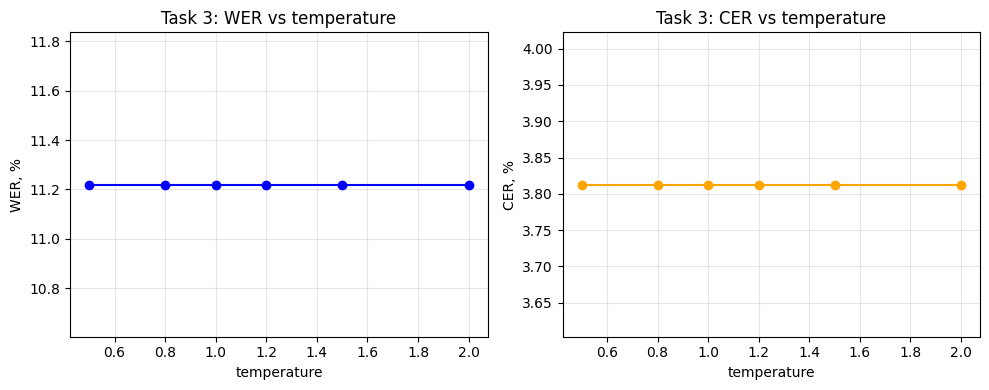

,temperature,wer,cer
0,0.5,0.112198,0.038128
1,0.8,0.112198,0.038128
2,1.0,0.112198,0.038128
3,1.2,0.112198,0.038128
4,1.5,0.112198,0.038128
5,2.0,0.112198,0.038128


In [ ]:
task2_df = plot_beam_width_results(task2)
display(task2_df)

task3_df = plot_temperature_results(task3, title_prefix='Task 3')
display(task3_df)

## Tasks 4 and 6

In [ ]:
sf_best = run_task4(libri_samples, decoder_lm)
rs_best = run_task6(libri_samples, decoder_lm)
qual_examples = run_task6_qualitative(libri_samples, decoder_lm, sf_best, rs_best)

print('Best shallow fusion params:', sf_best)
print('Best rescoring params:', rs_best)
display(pd.DataFrame(qual_examples))


Task 4: Shallow fusion sweep
alpha=0.01, beta=0.0: WER=0.1107, CER=0.0377
alpha=0.01, beta=0.5: WER=0.1105, CER=0.0376
alpha=0.01, beta=1.0: WER=0.1122, CER=0.0379
alpha=0.01, beta=1.5: WER=0.1132, CER=0.0379
alpha=0.05, beta=0.0: WER=0.1102, CER=0.0376
alpha=0.05, beta=0.5: WER=0.1105, CER=0.0375
alpha=0.05, beta=1.0: WER=0.1124, CER=0.0378
alpha=0.05, beta=1.5: WER=0.1132, CER=0.0379
alpha=0.1, beta=0.0: WER=0.1107, CER=0.0377
alpha=0.1, beta=0.5: WER=0.1100, CER=0.0375
alpha=0.1, beta=1.0: WER=0.1107, CER=0.0375
alpha=0.1, beta=1.5: WER=0.1129, CER=0.0379
alpha=0.5, beta=0.0: WER=0.1142, CER=0.0382
alpha=0.5, beta=0.5: WER=0.1112, CER=0.0377
alpha=0.5, beta=1.0: WER=0.1102, CER=0.0375
alpha=0.5, beta=1.5: WER=0.1107, CER=0.0375
alpha=1.0, beta=0.0: WER=0.1159, CER=0.0385
alpha=1.0, beta=0.5: WER=0.1164, CER=0.0386
alpha=1.0, beta=1.0: WER=0.1127, CER=0.0380
alpha=1.0, beta=1.5: WER=0.1102, CER=0.0376
alpha=2.0, beta=0.0: WER=0.1369, CER=0.0414
alpha=2.0, beta=0.5: WER=0.1252, CER=0

,idx,ref,beam,sf,rs
0,24,a fellow who was shut up in prison for life mi...,a fellow who as shut up in prison for life mig...,a fellow who as shut up in prison for life mig...,a fellow who as shut up in prison for life mig...
1,33,and why did andy call mister gurr father,and why did andy call mister gurfather,and why did andy call mister gur father,and why did andy call mister gur father
2,62,why your clothes don't fit you and your cap's ...,why you'r clothes ont fit you and you'r caps p...,why you'r clothes ont fit you and you'r caps p...,why you'r clothes ont fit you and you'r caps p...
3,79,that's right of course well armed,that's right of course willamed,that's right of course will amed,that's right of course will amed
4,81,awkward bit o country sir six miles row before...,alkward but a country sir six miles oro before...,alkward but a country sir six miles or o befor...,alkward but a country sir six miles oro before...
5,103,he swung round walked aft and began sweeping t...,he swung round walked aff and began sweeping t...,he swung round walked aff and began sweeping t...,he swung round walked aff and began sweeping t...
6,118,boy bout seventeen with a red cap no sir indee...,boy about seventeen with a red cap no sir and ...,boy about seventeen with a red cap no sir and ...,boy about seventeen wit a red cap no sir and d...
7,121,i said a lad bout seventeen in a red cap like ...,i said a lad bout seventeen an a red captlic y...,i said a lad bout seventeen an a red captlic y...,i said a lad bout seventeen and a red captlic ...
8,143,we weighed anchor and shahrazad perceived the ...,we wide anchar and sherazad perceived the down...,we wide anchar and sherazad perceived the down...,we wide anchar and cherazad perceived the down...
9,153,each that died we washed and shrouded in some ...,each that died we washed and shrowded in some ...,each that died we washed and shrowded in some ...,each that died we washed and shrowded in some ...


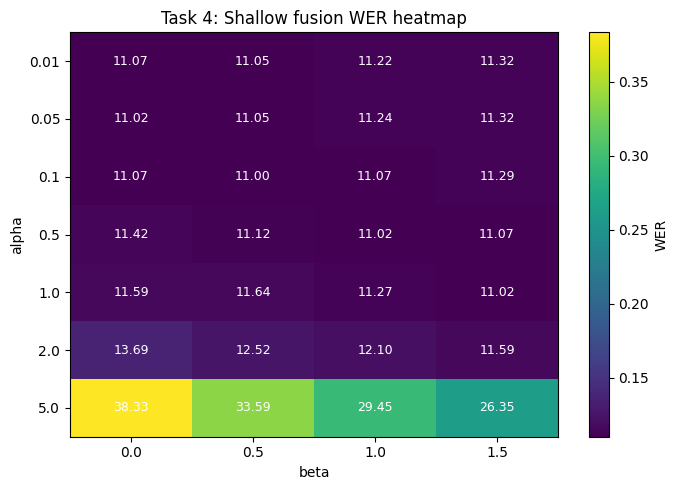

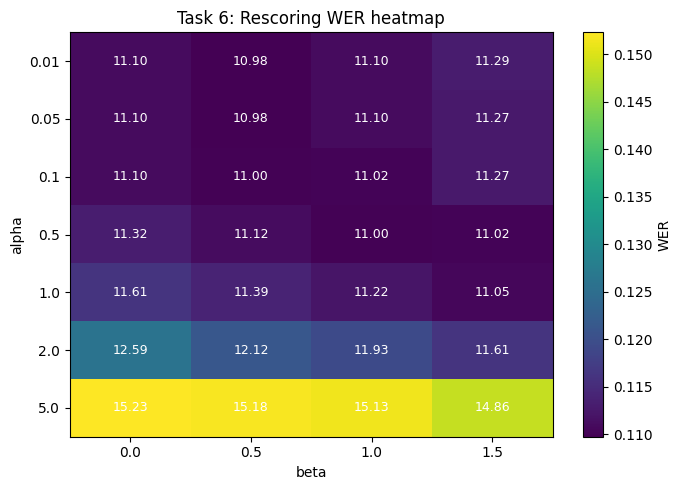

beta,0.0,0.5,1.0,1.5
alpha,,,,
0.01,0.110731,0.110486,0.112198,0.113175
0.05,0.110242,0.110486,0.112442,0.113175
0.10,0.110731,0.109998,0.110731,0.112931
0.50,0.114153,0.111220,0.110242,0.110731
1.00,0.115864,0.116353,0.112686,0.110242
2.00,0.136886,0.125153,0.120997,0.115864
5.00,0.383280,0.335859,0.294549,0.263505


beta,0.0,0.5,1.0,1.5
alpha,,,,
0.01,0.110975,0.109753,0.110975,0.112931
0.05,0.110975,0.109753,0.110975,0.112686
0.10,0.110975,0.109998,0.110242,0.112686
0.50,0.113175,0.111220,0.109998,0.110242
1.00,0.116109,0.113909,0.112198,0.110486
2.00,0.125886,0.121242,0.119286,0.116109
5.00,0.152286,0.151797,0.151308,0.148619


In [ ]:
task4_results = load_results('task4_shallow_fusion_sweep')
task6_results = load_results('task6_rescoring_sweep')

task4_pivot = plot_grid_from_results(task4_results, 'Task 4: Shallow fusion WER heatmap', value_key='wer')
task6_pivot = plot_grid_from_results(task6_results, 'Task 6: Rescoring WER heatmap', value_key='wer')

display(task4_pivot)
display(task6_pivot)

## Task 5

In [ ]:
task5 = run_task5(libri_samples, sf_best)
print('financial LM exists:', Path(FINANCIAL_LM).exists())
print('4-gram LM exists:', Path(LM_4GRAM).exists())


Task 5: 4-gram LM evaluation


/ssd/a.gorokhova/usr/anaconda3/envs/audio_itmo/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForS

saved -> results/task5_4gram_eval.json
{'alpha': 0.1, 'beta': 0.5, 'wer': 0.11415301882180395, 'cer': 0.038176444939683155}
financial LM exists: True
4-gram LM exists: True


## Tasks 7, 7b and 9

In [30]:
task7 = run_task7(libri_samples, earn_samples, decoder_no_lm, decoder_lm, sf_best, rs_best)
task7b = run_task7b(earn_samples, decoder_no_lm, decoder_lm, sf_best)
task9 = run_task9(libri_samples, earn_samples, sf_best, rs_best)

print(task7)
print(task7b)
print(task9)


Task 7: Cross-domain comparison
saved -> results/task7_cross_domain.json

Task 7b: Temperature sweep on Earnings22
T=0.5: greedy=0.5497, sf=0.5518
T=1.0: greedy=0.5497, sf=0.5536
T=1.5: greedy=0.5497, sf=0.5617
T=2.0: greedy=0.5497, sf=0.5771
saved -> results/task7b_temp_earnings22.json

Task 9: Compare LibriSpeech LM vs Financial LM


/ssd/a.gorokhova/usr/anaconda3/envs/audio_itmo/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForS

OSError: Cannot read model 'lm/financial-3gram.arpa.gz' (End of file Byte: 0)

In [ ]:
task9 = run_task9(libri_samples, earn_samples, sf_best, rs_best)

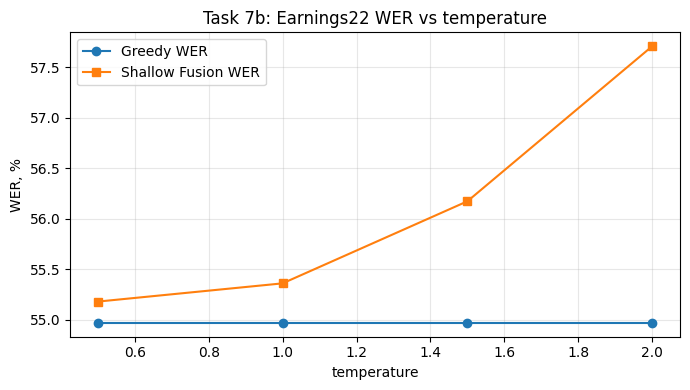

,temperature,greedy_wer,sf_wer
0,0.5,0.549699,0.551807
1,1.0,0.549699,0.553614
2,1.5,0.549699,0.561747
3,2.0,0.549699,0.577108


KeyError: 'sf'

In [31]:
task7b_results = load_results('task7b_temp_earnings22') if (RESULTS_DIR / 'task7b_temp_earnings22.json').exists() else None
if task7b_results is not None:
    task7b_df = plot_task7b_results(task7b_results)
    display(task7b_df)

if (RESULTS_DIR / 'task9_lm_comparison.json').exists():
    task9_results = load_results('task9_lm_comparison')
    rows = []
    for lm_name, ds_data in task9_results.items():
        for ds_name, metrics in ds_data.items():
            rows.append({'lm': lm_name, 'dataset': ds_name, 'method': 'sf', 'wer': metrics['sf']['wer'], 'cer': metrics['sf']['cer']})
            rows.append({'lm': lm_name, 'dataset': ds_name, 'method': 'rs', 'wer': metrics['rs']['wer'], 'cer': metrics['rs']['cer']})
    task9_df = pd.DataFrame(rows)
    display(task9_df)

    for dataset in task9_df['dataset'].unique():
        subset = task9_df[task9_df['dataset'] == dataset].copy()
        subset['label'] = subset['lm'] + '\n' + subset['method'].str.upper()

        plt.figure(figsize=(8, 4))
        plt.bar(subset['label'], subset['wer'])
        plt.title(f'Task 9: WER comparison on {dataset}')
        plt.ylabel('WER')
        plt.xticks(rotation=20)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.bar(subset['label'], subset['cer'], color='orange')
        plt.title(f'Task 9: CER comparison on {dataset}')
        plt.ylabel('CER')
        plt.xticks(rotation=20)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

result_files = sorted(RESULTS_DIR.glob('*.json'))
summary = [{'file': path.name, 'size_bytes': path.stat().st_size} for path in result_files]
display(pd.DataFrame(summary))